<a href="https://colab.research.google.com/github/lunecarvalho/newslens-project/blob/main/06_bertimbau_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.3 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [3]:
print("GPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU disponível: True
GPU: NVIDIA A100-SXM4-40GB


In [5]:
df = pd.read_csv("dataset_preprocessado.csv")

In [6]:
df.shape

(7199, 11)

In [7]:
df.columns

Index(['id', 'label', 'arquivo', 'texto_original', 'texto_preprocessado',
       'topico_bertopic', 'tema', 'tamanho_caracteres', 'tamanho_palavras',
       'texto_preprocessado_sem_acento', 'texto_lematizado'],
      dtype='object')

In [8]:
df["label"].value_counts()

,count
label,
falso,3600
verdadeiro,3599


In [9]:
X = df["texto_preprocessado"].fillna("")

y = df["label"].map({
    "falso": 0,
    "verdadeiro": 1
})

In [10]:
print(X.shape)
print(y.value_counts())

(7199,)
label
0    3600
1    3599
Name: count, dtype: int64


In [12]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [13]:
print("Treino:", len(X_treino))
print("Teste:", len(X_teste))

print("\nTreino:")
print(y_treino.value_counts())

print("\nTeste:")
print(y_teste.value_counts())

Treino: 5759
Teste: 1440

Treino:
label
0    2880
1    2879
Name: count, dtype: int64

Teste:
label
0    720
1    720
Name: count, dtype: int64


In [14]:
df_treino = pd.DataFrame({
    "texto": X_treino.values,
    "label": y_treino.values
})

df_teste = pd.DataFrame({
    "texto": X_teste.values,
    "label": y_teste.values
})

In [15]:
df_treino.head()

,texto,label
0,urgente: polícia de imigração dos eua prende l...,0
1,"o governador do maranhão, flávio dino (pc do b...",1
2,ataque em londres! pessoas atropeladas e esfaq...,0
3,a perícia da polícia federal encontrou evidênc...,1
4,"a presidente do stf, cármen lúcia, suspendeu e...",1


In [16]:
dataset_treino = Dataset.from_pandas(
    df_treino,
    preserve_index=False
)

dataset_teste = Dataset.from_pandas(
    df_teste,
    preserve_index=False
)

In [17]:
dataset_treino

Dataset({
    features: ['texto', 'label'],
    num_rows: 5759
})

In [18]:
modelo_nome = "neuralmind/bert-base-portuguese-cased"

In [19]:
tokenizer = AutoTokenizer.from_pretrained(
    modelo_nome
)

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/210k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [20]:
exemplo = df_treino["texto"].iloc[0]

tokens = tokenizer(
    exemplo,
    truncation=True,
    max_length=512
)

tokens.keys()

KeysView({'input_ids': [101, 5657, 11259, 131, 4522, 125, 11953, 298, 2779, 22278, 466, 323, 1340, 8613, 154, 171, 126, 22287, 22284, 22295, 173, 14689, 8588, 119, 125, 1365, 170, 3914, 182, 125, 872, 7485, 141, 738, 391, 22316, 117, 6153, 640, 3377, 2471, 21417, 201, 888, 1529, 125, 3986, 123, 5302, 190, 1945, 12131, 119, 123, 4522, 125, 11953, 298, 2779, 22278, 117, 173, 4495, 170, 123, 4522, 4015, 171, 1010, 215, 117, 466, 2071, 146, 1340, 8613, 154, 6153, 640, 3377, 122, 347, 1417, 5782, 300, 3377, 119, 2592, 506, 14874, 125, 15759, 22281, 125, 4025, 20109, 1319, 229, 4597, 12486, 3391, 3054, 1973, 117, 975, 266, 522, 285, 3185, 2097, 119, 123, 4205, 262, 13470, 423, 17441, 180, 126, 22294, 11775, 3226, 523, 1253, 934, 1125, 119, 3377, 407, 253, 15798, 240, 736, 3914, 1102, 271, 15348, 1538, 125, 2671, 986, 221, 146, 126, 22287, 22284, 22295, 202, 16176, 119, 123, 4597, 12486, 3391, 3054, 1973, 180, 126, 22294, 262, 975, 266, 522, 285, 3185, 2097, 113, 2506, 114, 122, 259, 7209, 34

In [21]:
comprimentos = []

for texto in df_treino["texto"]:
    tokens = tokenizer(
        texto,
        truncation=False,
        add_special_tokens=True
    )

    comprimentos.append(
        len(tokens["input_ids"])
    )

In [22]:
pd.Series(comprimentos).describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
)

,0
count,5759.000000
mean,257.147942
std,159.845691
min,14.000000
50%,222.000000
75%,313.000000
90%,426.000000
95%,517.000000
99%,803.520000
max,2789.000000


In [23]:
comprimentos_series = pd.Series(comprimentos)

print(
    "Acima de 512:",
    (comprimentos_series > 512).sum()
)

print(
    "Percentual:",
    round(
        (comprimentos_series > 512).mean() * 100,
        2
    ),
    "%"
)

Acima de 512: 295
Percentual: 5.12 %


In [25]:
MAX_LENGTH = 512

In [26]:
def tokenizar(batch):
    return tokenizer(
        batch["texto"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [27]:
dataset_treino_tokenizado = dataset_treino.map(
    tokenizar,
    batched=True
)

Map:   0%|          | 0/5759 [00:00<?, ? examples/s]

In [28]:
dataset_teste_tokenizado = dataset_teste.map(
    tokenizar,
    batched=True
)

Map:   0%|          | 0/1440 [00:00<?, ? examples/s]

In [29]:
dataset_treino_tokenizado = dataset_treino_tokenizado.remove_columns(
    ["texto"]
)

dataset_teste_tokenizado = dataset_teste_tokenizado.remove_columns(
    ["texto"]
)

In [30]:
dataset_treino_tokenizado

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5759
})

In [31]:
modelo_bert = AutoModelForSequenceClassification.from_pretrained(
    modelo_nome,
    num_labels=2
)

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

In [32]:
modelo_bert.config.id2label = {
    0: "Falsa",
    1: "Verdadeira"
}

modelo_bert.config.label2id = {
    "Falsa": 0,
    "Verdadeira": 1
}

In [33]:
def calcular_metricas(eval_pred):
    logits, labels = eval_pred

    previsoes = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, previsoes),
        "precision": precision_score(labels, previsoes),
        "recall": recall_score(labels, previsoes),
        "f1": f1_score(labels, previsoes)
    }

In [35]:
training_args = TrainingArguments(
    output_dir="./bertimbau_newslens",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    bf16=True,

    logging_steps=50,

    save_total_limit=2,

    report_to="none"
)

In [37]:
print("GPU:", torch.cuda.get_device_name(0))
print("BF16 suportado:", torch.cuda.is_bf16_supported())

GPU: NVIDIA A100-SXM4-40GB
BF16 suportado: True


In [38]:
trainer = Trainer(
    model=modelo_bert,
    args=training_args,
    train_dataset=dataset_treino_tokenizado,
    eval_dataset=dataset_teste_tokenizado,
    compute_metrics=calcular_metricas
)

In [39]:
resultado_treino = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.045731,0.114756,0.981944,0.992898,0.970833,0.981742
2,0.032440,0.043230,0.990972,0.987586,0.994444,0.991003
3,0.016961,0.049896,0.990972,0.995792,0.986111,0.990928


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [40]:
resultado_treino

TrainOutput(global_step=2160, training_loss=0.05452185773621615, metrics={'train_runtime': 131.7907, 'train_samples_per_second': 131.094, 'train_steps_per_second': 16.39, 'total_flos': 4545769703454720.0, 'train_loss': 0.05452185773621615, 'epoch': 3.0})

In [41]:
metricas_bert = trainer.evaluate()

metricas_bert

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.016961,0.043230,3,0.990972,0.987586,0.994444,0.991003


{'eval_loss': 0.04322988539934158,
 'eval_accuracy': 0.9909722222222223,
 'eval_precision': 0.9875862068965517,
 'eval_recall': 0.9944444444444445,
 'eval_f1': 0.9910034602076124}

In [43]:
load_best_model_at_end=True
metric_for_best_model="f1"

In [44]:
predicoes = trainer.predict(
    dataset_teste_tokenizado
)

logits = predicoes.predictions
y_pred_bert = np.argmax(logits, axis=-1)

In [45]:
print(
    classification_report(
        y_teste,
        y_pred_bert,
        target_names=["Falsa", "Verdadeira"]
    )
)

              precision    recall  f1-score   support

       Falsa       0.99      0.99      0.99       720
  Verdadeira       0.99      0.99      0.99       720

    accuracy                           0.99      1440
   macro avg       0.99      0.99      0.99      1440
weighted avg       0.99      0.99      0.99      1440



In [46]:
matriz_bert = confusion_matrix(
    y_teste,
    y_pred_bert
)

matriz_bert

array([[711,   9],
       [  4, 716]])

In [47]:
from sklearn.model_selection import train_test_split

X = df["texto_preprocessado"].fillna("")

y = df["label"].map({
    "falso": 0,
    "verdadeiro": 1
})

# 80% treino + 20% temporário
X_treino, X_temp, y_treino, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 20% temporário -> 10% validação + 10% teste
X_validacao, X_teste_final, y_validacao, y_teste_final = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [48]:
print("Treino:", len(X_treino))
print("Validação:", len(X_validacao))
print("Teste final:", len(X_teste_final))

print("\nTreino:")
print(y_treino.value_counts())

print("\nValidação:")
print(y_validacao.value_counts())

print("\nTeste final:")
print(y_teste_final.value_counts())

Treino: 5759
Validação: 720
Teste final: 720

Treino:
label
0    2880
1    2879
Name: count, dtype: int64

Validação:
label
0    360
1    360
Name: count, dtype: int64

Teste final:
label
0    360
1    360
Name: count, dtype: int64


In [49]:
df_treino = pd.DataFrame({
    "texto": X_treino.values,
    "label": y_treino.values
})

df_validacao = pd.DataFrame({
    "texto": X_validacao.values,
    "label": y_validacao.values
})

df_teste_final = pd.DataFrame({
    "texto": X_teste_final.values,
    "label": y_teste_final.values
})

In [50]:
from datasets import Dataset

dataset_treino = Dataset.from_pandas(
    df_treino,
    preserve_index=False
)

dataset_validacao = Dataset.from_pandas(
    df_validacao,
    preserve_index=False
)

dataset_teste_final = Dataset.from_pandas(
    df_teste_final,
    preserve_index=False
)

In [51]:
MAX_LENGTH = 512

def tokenizar(batch):
    return tokenizer(
        batch["texto"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

In [52]:
dataset_treino_tokenizado = dataset_treino.map(
    tokenizar,
    batched=True
)

dataset_validacao_tokenizado = dataset_validacao.map(
    tokenizar,
    batched=True
)

dataset_teste_final_tokenizado = dataset_teste_final.map(
    tokenizar,
    batched=True
)

Map:   0%|          | 0/5759 [00:00<?, ? examples/s]

Map:   0%|          | 0/720 [00:00<?, ? examples/s]

Map:   0%|          | 0/720 [00:00<?, ? examples/s]

In [53]:
dataset_treino_tokenizado = dataset_treino_tokenizado.remove_columns(["texto"])

dataset_validacao_tokenizado = dataset_validacao_tokenizado.remove_columns(["texto"])

dataset_teste_final_tokenizado = dataset_teste_final_tokenizado.remove_columns(["texto"])

In [54]:
print(dataset_treino_tokenizado)
print(dataset_validacao_tokenizado)
print(dataset_teste_final_tokenizado)

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 5759
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 720
})
Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 720
})


In [55]:
modelo_bert_final = AutoModelForSequenceClassification.from_pretrained(
    modelo_nome,
    num_labels=2
)

modelo_bert_final.config.id2label = {
    0: "Falsa",
    1: "Verdadeira"
}

modelo_bert_final.config.label2id = {
    "Falsa": 0,
    "Verdadeira": 1
}

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from th

In [56]:
training_args_final = TrainingArguments(
    output_dir="./bertimbau_newslens_final",

    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    bf16=True,

    logging_steps=50,
    save_total_limit=2,

    report_to="none"
)

In [57]:
trainer_final = Trainer(
    model=modelo_bert_final,
    args=training_args_final,
    train_dataset=dataset_treino_tokenizado,
    eval_dataset=dataset_validacao_tokenizado,
    compute_metrics=calcular_metricas
)

In [58]:
resultado_treino_final = trainer_final.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.081582,0.056191,0.990278,0.988920,0.991667,0.990291
2,0.003332,0.035762,0.991667,0.986264,0.997222,0.991713
3,0.000140,0.034315,0.993056,0.991690,0.994444,0.993065


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [59]:
resultado_treino_final

TrainOutput(global_step=2160, training_loss=0.055897794289382914, metrics={'train_runtime': 127.5913, 'train_samples_per_second': 135.409, 'train_steps_per_second': 16.929, 'total_flos': 4545769703454720.0, 'train_loss': 0.055897794289382914, 'epoch': 3.0})

In [60]:
trainer_final.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000140,0.034315,3,0.993056,0.991690,0.994444,0.993065


{'eval_loss': 0.0343150831758976,
 'eval_accuracy': 0.9930555555555556,
 'eval_precision': 0.9916897506925207,
 'eval_recall': 0.9944444444444445,
 'eval_f1': 0.9930651872399445}

In [61]:
predicoes_teste_final = trainer_final.predict(
    dataset_teste_final_tokenizado
)

y_pred_bert_final = np.argmax(
    predicoes_teste_final.predictions,
    axis=-1
)

In [62]:
print(
    classification_report(
        y_teste_final,
        y_pred_bert_final,
        target_names=["Falsa", "Verdadeira"]
    )
)

              precision    recall  f1-score   support

       Falsa       0.99      1.00      0.99       360
  Verdadeira       1.00      0.99      0.99       360

    accuracy                           0.99       720
   macro avg       0.99      0.99      0.99       720
weighted avg       0.99      0.99      0.99       720



In [63]:
matriz_confusao_bert_final = confusion_matrix(
    y_teste_final,
    y_pred_bert_final
)

matriz_confusao_bert_final

array([[359,   1],
       [  3, 357]])

In [64]:
metricas_teste_bert = {
    "accuracy": accuracy_score(y_teste_final, y_pred_bert_final),
    "precision": precision_score(y_teste_final, y_pred_bert_final),
    "recall": recall_score(y_teste_final, y_pred_bert_final),
    "f1": f1_score(y_teste_final, y_pred_bert_final)
}

metricas_teste_bert

{'accuracy': 0.9944444444444445,
 'precision': 0.9972067039106145,
 'recall': 0.9916666666666667,
 'f1': 0.9944289693593314}

In [65]:
metricas_falsa_bert = {
    "precision_falsa": precision_score(
        y_teste_final,
        y_pred_bert_final,
        pos_label=0
    ),
    "recall_falsa": recall_score(
        y_teste_final,
        y_pred_bert_final,
        pos_label=0
    ),
    "f1_falsa": f1_score(
        y_teste_final,
        y_pred_bert_final,
        pos_label=0
    )
}

metricas_falsa_bert

{'precision_falsa': 0.9917127071823204,
 'recall_falsa': 0.9972222222222222,
 'f1_falsa': 0.9944598337950139}

In [66]:
df_erros_bert = df.loc[X_teste_final.index].copy()

df_erros_bert["label_real"] = y_teste_final
df_erros_bert["label_predito"] = y_pred_bert_final

df_erros_bert["classe_real"] = df_erros_bert["label_real"].map({
    0: "Falsa",
    1: "Verdadeira"
})

df_erros_bert["classe_predita"] = df_erros_bert["label_predito"].map({
    0: "Falsa",
    1: "Verdadeira"
})

df_erros_bert = df_erros_bert[
    df_erros_bert["label_real"] != df_erros_bert["label_predito"]
].copy()

print("Total de erros:", len(df_erros_bert))

Total de erros: 4


In [67]:
df_erros_bert[
    [
        "tema",
        "classe_real",
        "classe_predita",
        "texto_original"
    ]
]

,tema,classe_real,classe_predita,texto_original
3110,Corrupção,Falsa,Verdadeira,Delação de Palocci ira derrubar Caixa Econômic...
6585,Entretenimento,Verdadeira,Falsa,Corpo de Domingos Montagner é liberado do IML ...
4024,Internacional,Verdadeira,Falsa,O homem mais poderoso do mundo. Xi Jinping é u...
6136,Saúde,Verdadeira,Falsa,OMS declara fim de emergência global por zika;...


### Comparação SVM e BERTimbau:

In [68]:
import joblib

modelo_svm_final = joblib.load(
    "newslens_svm_pipeline.joblib"
)

In [69]:
X_teste_final_svm = df.loc[
    X_teste_final.index,
    "texto_preprocessado_sem_acento"
].fillna("")

In [70]:
print("Teste BERTimbau:", len(X_teste_final))
print("Teste SVM:", len(X_teste_final_svm))

print(
    "Mesmos índices:",
    X_teste_final.index.equals(X_teste_final_svm.index)
)

Teste BERTimbau: 720
Teste SVM: 720
Mesmos índices: True


In [71]:
y_pred_svm_final = modelo_svm_final.predict(
    X_teste_final_svm
)

In [72]:
print(
    classification_report(
        y_teste_final,
        y_pred_svm_final,
        target_names=["Falsa", "Verdadeira"]
    )
)

              precision    recall  f1-score   support

       Falsa       0.93      0.91      0.92       360
  Verdadeira       0.91      0.93      0.92       360

    accuracy                           0.92       720
   macro avg       0.92      0.92      0.92       720
weighted avg       0.92      0.92      0.92       720



In [73]:
matriz_confusao_svm_final = confusion_matrix(
    y_teste_final,
    y_pred_svm_final
)

matriz_confusao_svm_final

array([[328,  32],
       [ 24, 336]])

In [74]:
metricas_svm_teste_final = {
    "accuracy": accuracy_score(
        y_teste_final,
        y_pred_svm_final
    ),
    "precision": precision_score(
        y_teste_final,
        y_pred_svm_final
    ),
    "recall": recall_score(
        y_teste_final,
        y_pred_svm_final
    ),
    "f1": f1_score(
        y_teste_final,
        y_pred_svm_final
    )
}

metricas_svm_teste_final

{'accuracy': 0.9222222222222223,
 'precision': 0.9130434782608695,
 'recall': 0.9333333333333333,
 'f1': 0.9230769230769231}

In [75]:
comparacao_modelos = pd.DataFrame({
    "Modelo": ["Linear SVM", "BERTimbau"],
    "Accuracy": [
        0.9222222222222223,
        0.9944444444444445
    ],
    "Precision": [
        0.9130434782608695,
        0.9972067039106145
    ],
    "Recall": [
        0.9333333333333333,
        0.9916666666666667
    ],
    "F1-score": [
        0.9230769230769231,
        0.9944289693593314
    ]
})

comparacao_modelos

,Modelo,Accuracy,Precision,Recall,F1-score
0,Linear SVM,0.922222,0.913043,0.933333,0.923077
1,BERTimbau,0.994444,0.997207,0.991667,0.994429


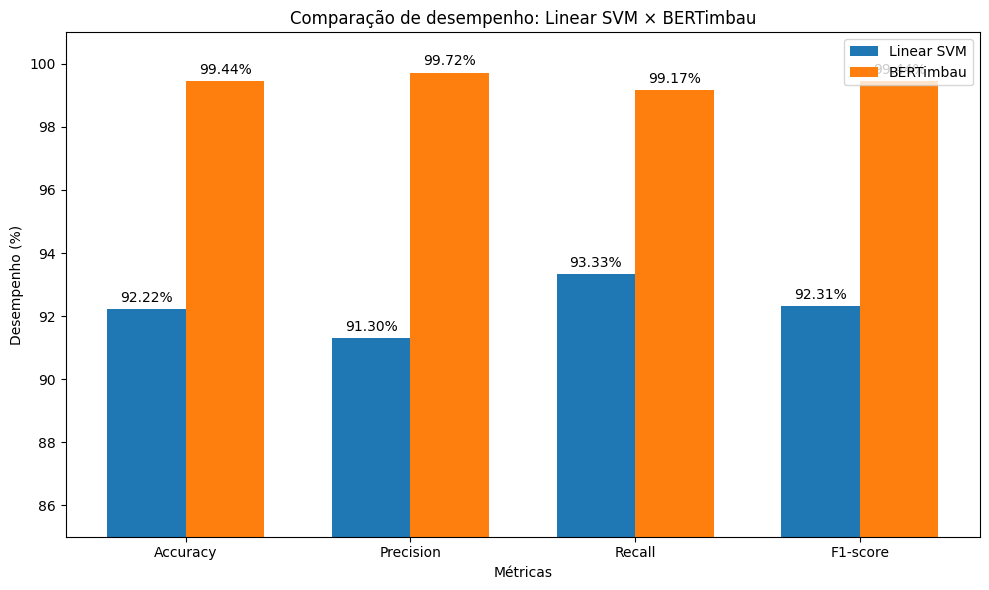

In [76]:
import matplotlib.pyplot as plt
import numpy as np

metricas = ["Accuracy", "Precision", "Recall", "F1-score"]

svm = comparacao_modelos.loc[
    comparacao_modelos["Modelo"] == "Linear SVM",
    metricas
].values[0] * 100

bert = comparacao_modelos.loc[
    comparacao_modelos["Modelo"] == "BERTimbau",
    metricas
].values[0] * 100

x = np.arange(len(metricas))
largura = 0.35

plt.figure(figsize=(10, 6))

barras_svm = plt.bar(
    x - largura/2,
    svm,
    largura,
    label="Linear SVM"
)

barras_bert = plt.bar(
    x + largura/2,
    bert,
    largura,
    label="BERTimbau"
)

plt.ylabel("Desempenho (%)")
plt.xlabel("Métricas")
plt.title("Comparação de desempenho: Linear SVM × BERTimbau")

plt.xticks(x, metricas)

# Facilita visualizar diferenças entre modelos
plt.ylim(85, 101)

plt.legend()

plt.bar_label(
    barras_svm,
    fmt="%.2f%%",
    padding=3
)

plt.bar_label(
    barras_bert,
    fmt="%.2f%%",
    padding=3
)

plt.tight_layout()
plt.show()

In [77]:
import os

os.makedirs("models/bertimbau_newslens", exist_ok=True)

trainer_final.save_model(
    "models/bertimbau_newslens"
)

tokenizer.save_pretrained(
    "models/bertimbau_newslens"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/bertimbau_newslens/tokenizer_config.json',
 'models/bertimbau_newslens/tokenizer.json')

In [78]:
import os

os.listdir("models/bertimbau_newslens")

['config.json',
 'training_args.bin',
 'tokenizer.json',
 'model.safetensors',
 'tokenizer_config.json']

In [79]:
resultados_bert_final = pd.DataFrame({
    "Modelo": ["BERTimbau"],
    "Accuracy": [0.9944444444444445],
    "Precision_Verdadeira": [0.9972067039106145],
    "Recall_Verdadeira": [0.9916666666666667],
    "F1_Verdadeira": [0.9944289693593314],
    "Precision_Falsa": [0.9917127071823204],
    "Recall_Falsa": [0.9972222222222222],
    "F1_Falsa": [0.9944598337950139]
})

resultados_bert_final.to_csv(
    "metricas_bertimbau_final.csv",
    index=False
)

resultados_bert_final

,Modelo,Accuracy,Precision_Verdadeira,Recall_Verdadeira,F1_Verdadeira,Precision_Falsa,Recall_Falsa,F1_Falsa
0,BERTimbau,0.994444,0.997207,0.991667,0.994429,0.991713,0.997222,0.99446


In [80]:
!zip -r bertimbau_newslens.zip models/bertimbau_newslens

  adding: models/bertimbau_newslens/ (stored 0%)
  adding: models/bertimbau_newslens/config.json (deflated 56%)
  adding: models/bertimbau_newslens/training_args.bin (deflated 53%)
  adding: models/bertimbau_newslens/tokenizer.json (deflated 72%)
  adding: models/bertimbau_newslens/model.safetensors (deflated 7%)
  adding: models/bertimbau_newslens/tokenizer_config.json (deflated 43%)


In [81]:
from google.colab import files

files.download("bertimbau_newslens.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>